In [17]:
# --- Cell 1 ---
%load_ext autoreload
%autoreload 2

# import warnings
# warnings.filterwarnings('ignore', category=UserWarning, module='tqdm')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset

# Import the text cleaning function you wrote in Step 2
import sys
sys.path.append('..') # Ensure the notebook can find the src folder
from src.preprocess import clean_text

# Set plotting style
plt.style.use('ggplot')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# --- Cell 2 ---
print("Loading IMDb dataset...")
dataset = load_dataset("imdb")

# Convert to Pandas DataFrame for easier EDA
df_train = dataset['train'].to_pandas()
print(f"Dataset shape: {df_train.shape}")
df_train.head()

Loading IMDb dataset...


Dataset shape: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [3]:
# --- Cell 2 ---
print("Loading IMDb dataset...")
dataset = load_dataset("imdb")

# Convert to Pandas DataFrame for easier EDA
df_train = dataset['train'].to_pandas()
print(f"Dataset shape: {df_train.shape}")
df_train.head()

Loading IMDb dataset...


Dataset shape: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


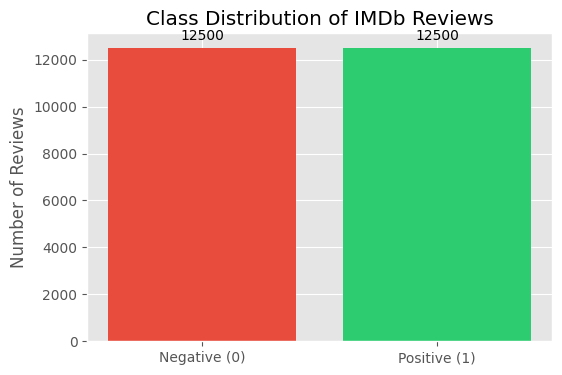

In [3]:
# --- Cell 3 ---
# 0 = Negative, 1 = Positive
label_counts = df_train['label'].value_counts()

plt.figure(figsize=(6, 4))
bars = plt.bar(['Negative (0)', 'Positive (1)'], label_counts.values, color=['#e74c3c', '#2ecc71'])
plt.title('Class Distribution of IMDb Reviews')
plt.ylabel('Number of Reviews')

# Add the text counts on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 200, yval, ha='center', va='bottom')

plt.show()

Cleaning text and calculating sequence lengths... (This might take a minute)
------------------------------
Minimum length: 10 words
Maximum length: 2494 words
Mean length:    236.87 words
90th Percentile:463 words
------------------------------


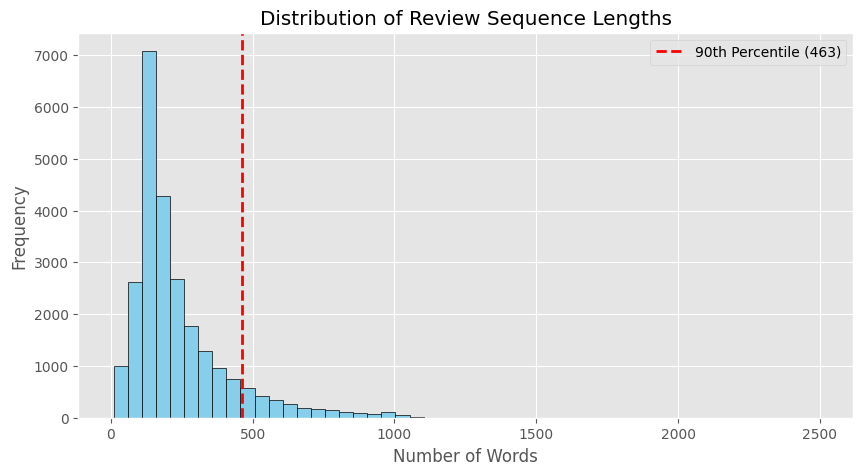

In [4]:
# --- Cell 4 ---
# Apply the clean_text function and calculate word counts for each review
print("Cleaning text and calculating sequence lengths... (This might take a minute)")
df_train['clean_text'] = df_train['text'].apply(clean_text)
df_train['seq_length'] = df_train['clean_text'].apply(lambda x: len(x.split()))

# Calculate required statistics
min_len = df_train['seq_length'].min()
max_len = df_train['seq_length'].max()
mean_len = df_train['seq_length'].mean()
percentile_90 = np.percentile(df_train['seq_length'], 90)

print("-" * 30)
print(f"Minimum length: {min_len} words")
print(f"Maximum length: {max_len} words")
print(f"Mean length:    {mean_len:.2f} words")
print(f"90th Percentile:{percentile_90:.0f} words")
print("-" * 30)

# Plot a histogram to visualize the distribution
plt.figure(figsize=(10, 5))
plt.hist(df_train['seq_length'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(percentile_90, color='red', linestyle='dashed', linewidth=2, label=f'90th Percentile ({percentile_90:.0f})')
plt.title('Distribution of Review Sequence Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.show()

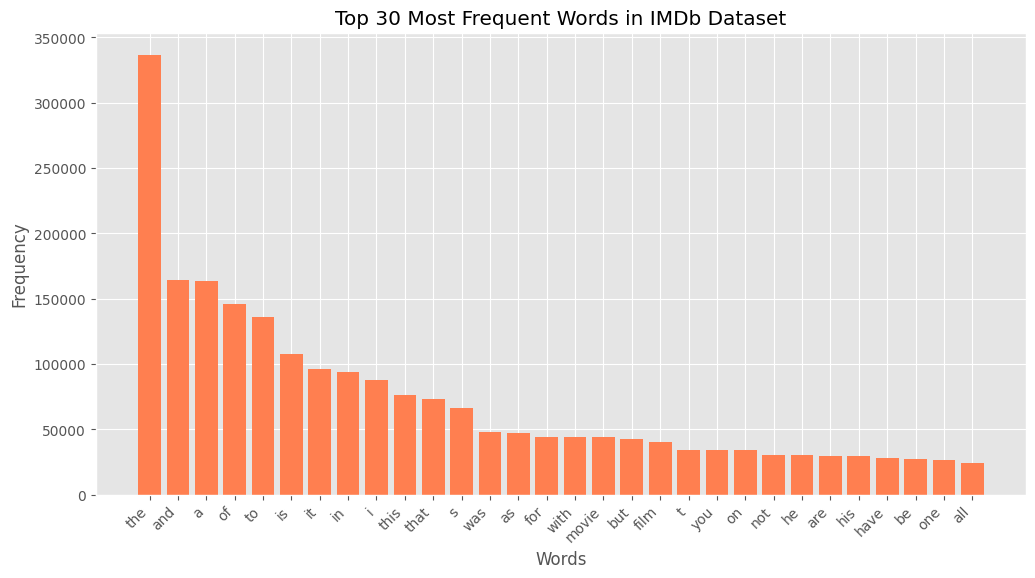

In [5]:
# --- Cell 5 ---
# Aggregate all words into one giant list
all_words = ' '.join(df_train['clean_text']).split()

# Count frequencies
word_counts = Counter(all_words)
top_30 = word_counts.most_common(30)

# Unpack the tuples for plotting
words, counts = zip(*top_30)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='coral')
plt.title('Top 30 Most Frequent Words in IMDb Dataset')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.show()

In [6]:
# --- Cell 6 ---
print("--- 3 Representative POSITIVE Reviews ---")
pos_samples = df_train[df_train['label'] == 1].sample(3, random_state=42)
for idx, row in pos_samples.iterrows():
    print(f"Review:\n{row['text'][:500]}...\n")

print("\n" + "="*50 + "\n")

print("--- 3 Representative NEGATIVE Reviews ---")
neg_samples = df_train[df_train['label'] == 0].sample(3, random_state=42)
for idx, row in neg_samples.iterrows():
    print(f"Review:\n{row['text'][:500]}...\n")

--- 3 Representative POSITIVE Reviews ---
Review:
This movie is to Halloween what the hilarious "Christmas Story" is to Christmas: both are relatively low-budget, no-big-name-stars type films...and both are two of the absolute greatest and funniest movies available, both seasonal CLASSICS!!! "Spaced Invaders" comes galloping out right from the start with warmth and humor and a superb cast of characters...all five goofy Martians, Klembecker the Realtor, Russell the deputy, Vern at the "fuel dispensing depot" and so many more! You just have to se...

Review:
Good western filmed in the rocky Arizona wilds. Lots of tough guys throughout; Cobern's character seemed to rock back and forth between a raging psycho and a laid back type. Several holes appeared in the picture, but not enough to offset it being exciting and worth seeing. One really dumb scene shows Heston emptying .45 cases of their powder and collecting it in a sack for the purpose of starting a fire. A. To gather that much gunpow